In [2]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----------------------------- ---------- 7.1/9.6 MB 36.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 28.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Trend, seasonality

Because stock market data grows exponentially over long periods, an multiplicative model is used instead of an additive one. Alternatively, we can use STL (Seasonal and Trend decomposition using Loess), which handles complex non-linear trends much better.

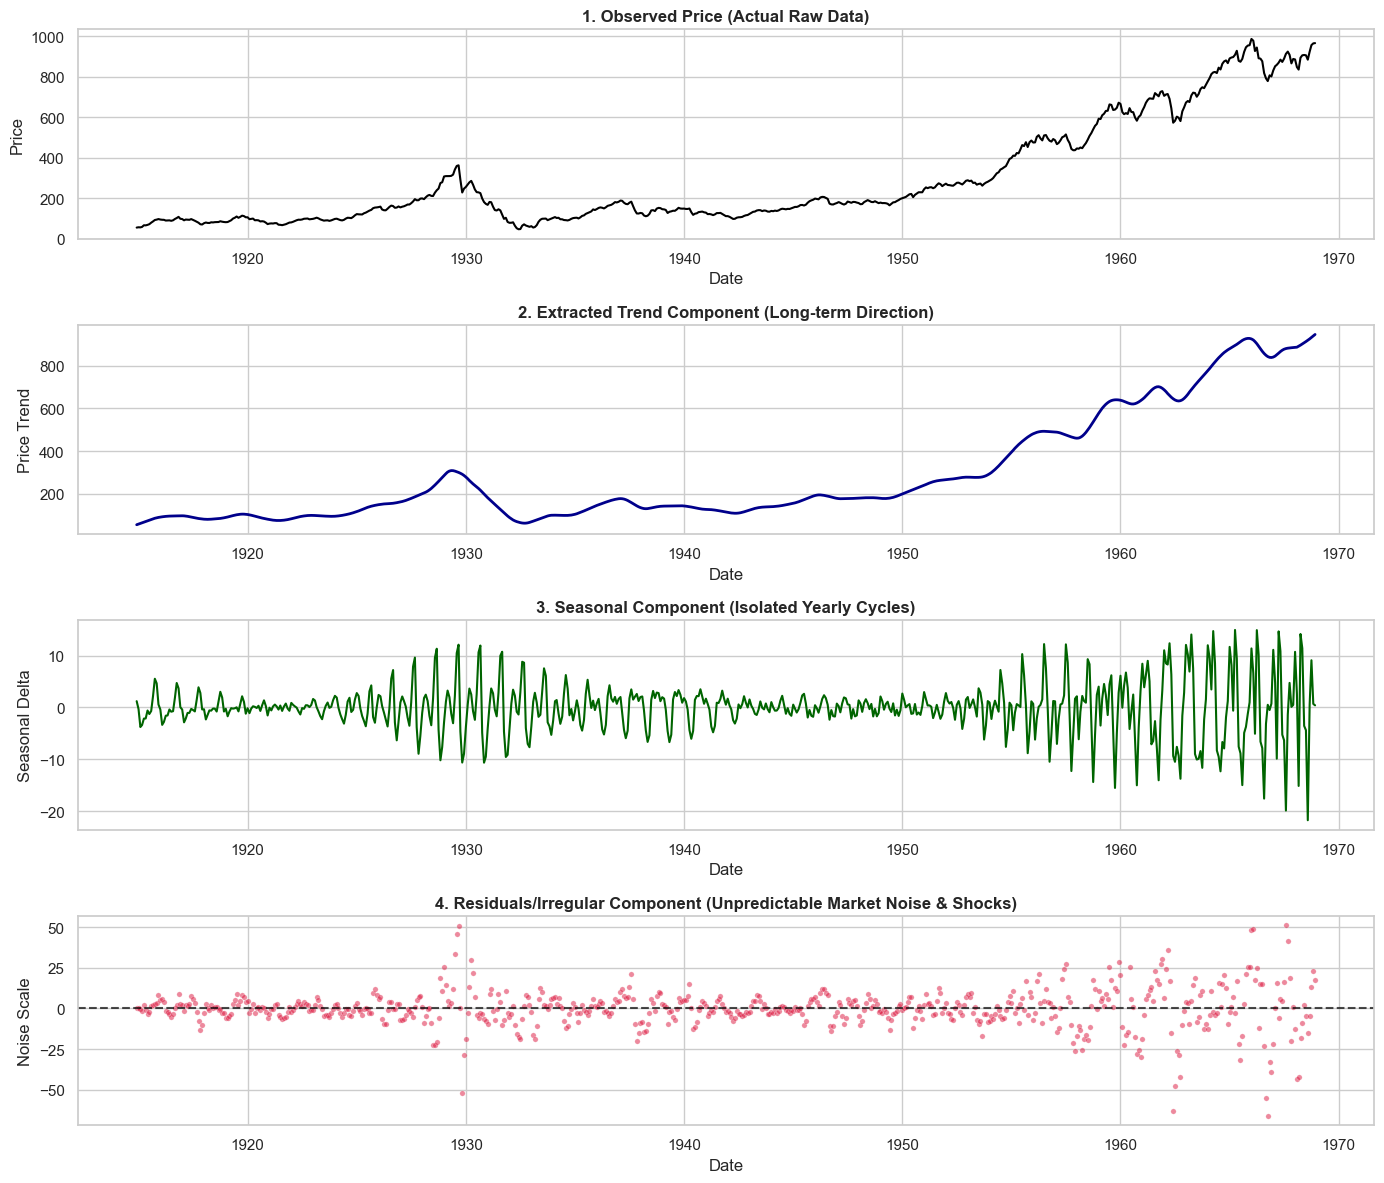

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL

# --- 1. PREPARE THE DATAFRAME ---
df = sns.load_dataset("dowjones")
df["Date"] = pd.to_datetime(df["Date"])

# Time-series decomposition requires a clean, datetime-indexed dataframe
df_ts = df.set_index("Date").copy()

# Crucial for statsmodels: Explicitly set the data frequency to Monthly ('MS')
df_ts = df_ts.asfreq("MS")

# Handle any missing values caused by re-indexing via linear interpolation
df_ts["Price"] = df_ts["Price"].interpolate(method="linear")

# --- 2. EXECUTE THE ADVANCED STL DECOMPOSITION ---
# stl handles structural trend shifts better than traditional classical decomposition
# seasonal=13 isolates annual (12-month) cyclic patterns effectively
stl = STL(df_ts["Price"], seasonal=13)
res = stl.fit()

# --- 3. EXTRACT AND STRUCTURALLY MAP THE COMPONENTS ---
df_ts["Trend"] = res.trend
df_ts["Seasonal"] = res.seasonal
df_ts["Residual"] = res.resid

# --- 4. VISUALISE THE MATRIX COMPONENTS ---
plt.figure(figsize=(14, 12))
sns.set_theme(style="whitegrid")

# Plot 1: Observed (The raw reality)
plt.subplot(4, 1, 1)
sns.lineplot(data=df_ts, x=df_ts.index, y="Price", color="black", linewidth=1.5)
plt.title("1. Observed Price (Actual Raw Data)", fontsize=12, fontweight="bold")
plt.ylabel("Price")

# Plot 2: Trend (The underlying macro-economic movement)
plt.subplot(4, 1, 2)
sns.lineplot(data=df_ts, x=df_ts.index, y="Trend", color="darkblue", linewidth=2)
plt.title(
    "2. Extracted Trend Component (Long-term Direction)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Price Trend")

# Plot 3: Seasonal (The repeating monthly/annual waves)
plt.subplot(4, 1, 3)
sns.lineplot(data=df_ts, x=df_ts.index, y="Seasonal", color="darkgreen")
plt.title(
    "3. Seasonal Component (Isolated Yearly Cycles)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Seasonal Delta")

# Plot 4: Residuals (Noise, unpredictable shocks, market crashes)
plt.subplot(4, 1, 4)
sns.scatterplot(
    data=df_ts, x=df_ts.index, y="Residual", color="crimson", alpha=0.5, s=15
)
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title(
    "4. Residuals/Irregular Component (Unpredictable Market Noise & Shocks)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Noise Scale")

plt.tight_layout()
plt.show()



Mathematical Framework Breakdown

Observed Data (\(Y_{t}\)): The original raw timeline series graph you see at the top.

Trend (\(T_{t}\)): The smooth non-linear path showing where the market is going overall, completely stripped of monthly calendar noise.

Seasonal (\(S_{t}\)): The rigid, repeating wave pattern. If you zoom in on this plot, you will see a matching pattern repeating precisely every 12 months.

Residuals (\(I_{t}\)): What remains after removing the trend and seasonality (\(Y_t - T_t - S_t\)). Spikes in this bottom graph isolate major global macro-economic disruptions and unexpected market crashes.

# Are we ready fow ARIMA test ?
To evaluate if the residuals are ready for an ARIMA forecasting model, we use the Augmented Dickey-Fuller (ADF) test.

An ARIMA model requires the input data series to be stationary, meaning its mean, variance, and autocorrelation structure do not change over time. Since the original index has a heavy upward trend, testing the raw data would fail. However, a successful decomposition should leave behind stationary, zero-mean white noise residuals.Here is the complete script to run the ADF test on your df residuals and interpret the mathematical results:

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# --- [Re-using the prior STL setup for context] ---
df = sns.load_dataset("dowjones")
df["Date"] = pd.to_datetime(df["Date"])
df_ts = df.set_index("Date").asfreq("MS")
df_ts["Price"] = df_ts["Price"].interpolate(method="linear")

from statsmodels.tsa.seasonal import STL

res = STL(df_ts["Price"], seasonal=13).fit()
df_ts["Residual"] = res.resid

# --- 1. EXECUTE THE AUGMENTED DICKEY-FULLER TEST ---
# We drop NaN values if any exist to prevent calculation failures
adf_result = adfuller(df_ts["Residual"].dropna())

# --- 2. EXTRACT AND STRUCTURALLY MAP THE METRICS ---
adf_statistic = adf_result[0]
p_value = adf_result[1]
critical_values = adf_result[4]

# --- 3. PRINT RESULTS TERMINAL REPORT ---
print("=" * 45)
print("      AUGMENTED DICKEY-FULLER TEST RESULTS    ")
print("=" * 45)
print(f"ADF Statistic      : {adf_statistic:.4f}")
print(f"p-value            : {p_value:.4e}")
print("\nCritical Values Thresholds:")
for key, value in critical_values.items():
    print(f"   {key:<15}: {value:.4f}")
print("=" * 45)

# --- 4. MATHEMATICAL INTERPRETATION ---
print("\n--- Model Readiness Conclusion ---")
if p_value <= 0.05:
    print(
        "RESULT: Reject the Null Hypothesis (H0). The residuals are STATIONARY."
    )
    print(
        "ARIMA READY: Yes! The STL decomposition successfully cleaned the trend/seasonality."
    )
else:
    print(
        "RESULT: Fail to reject the Null Hypothesis (H0). The residuals are NON-STATIONARY."
    )
    print(
        "ARIMA READY: No. You must apply further differencing (d) before fitting ARIMA."
    )
print("=" * 45)


      AUGMENTED DICKEY-FULLER TEST RESULTS    
ADF Statistic      : -9.2020
p-value            : 1.9904e-15

Critical Values Thresholds:
   1%             : -3.4407
   5%             : -2.8661
   10%            : -2.5692

--- Model Readiness Conclusion ---
RESULT: Reject the Null Hypothesis (H0). The residuals are STATIONARY.
ARIMA READY: Yes! The STL decomposition successfully cleaned the trend/seasonality.


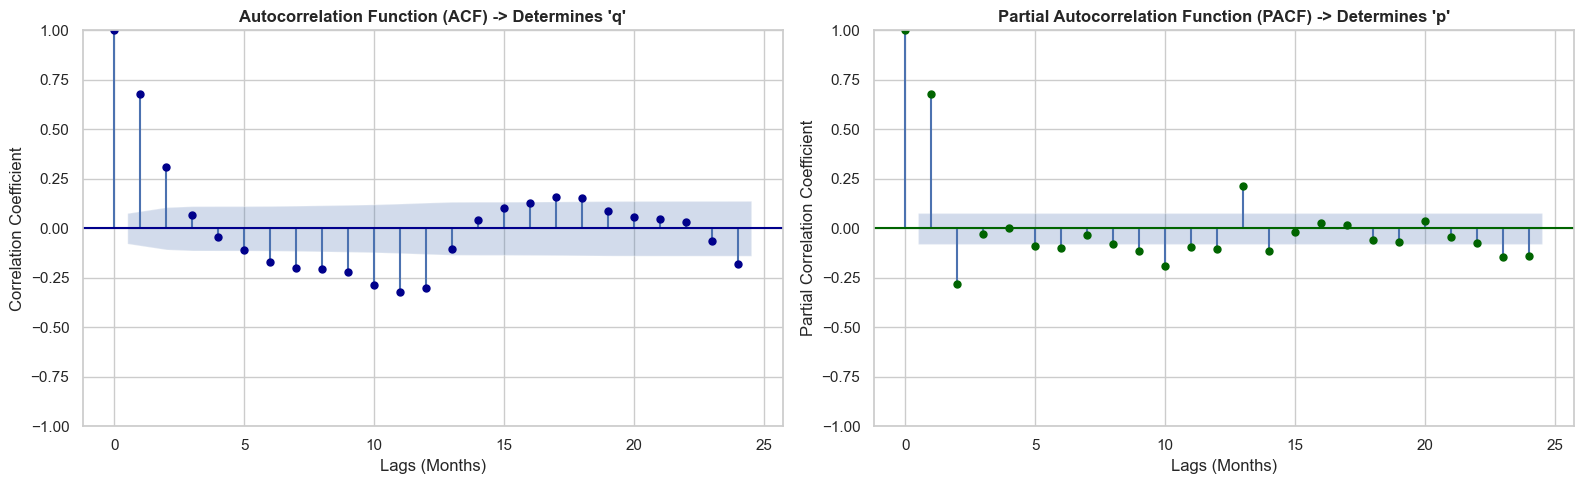

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

# --- 1. DATA PREPARATION & DECOMPOSITION ---
df = sns.load_dataset("dowjones")
df["Date"] = pd.to_datetime(df["Date"])
df_ts = df.set_index("Date").asfreq("MS")
df_ts["Price"] = df_ts["Price"].interpolate(method="linear")

# Extract residuals
res = STL(df_ts["Price"], seasonal=13).fit()
residuals = res.resid.dropna()

# --- 2. PLOT ACF AND PACF DIAGNOSTICS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Plot Autocorrelation (ACF) -> Identifies 'q' (MA terms)
plot_acf(residuals, ax=axes[0], lags=24, alpha=0.05, color="darkblue")
axes[0].set_title("Autocorrelation Function (ACF) -> Determines 'q'", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Lags (Months)")
axes[0].set_ylabel("Correlation Coefficient")

# Plot Partial Autocorrelation (PACF) -> Identifies 'p' (AR terms)
plot_pacf(residuals, ax=axes[1], lags=24, alpha=0.05, color="darkgreen", method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF) -> Determines 'p'", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Lags (Months)")
axes[1].set_ylabel("Partial Correlation Coefficient")

plt.tight_layout()
plt.show()
